# **PART 3: NLP & SEQUENCE MODELING MINI PROJECT**

# Task 1: Dataset Understanding

In [66]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [67]:
# Downloading NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [68]:
df = pd.read_csv('customer_support_text_classification.csv')
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [69]:
print("Number of records:", len(df))

Number of records: 1500


In [70]:
print(df['sentiment_label'].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [71]:
df['customer_message'].head()

,customer_message
0,I need information about the payment process. ...
1,I need information about the payment process.
2,The refund process was fast and convenient. I ...
3,My refund is still pending and this experience...
4,Please tell me how to update my account details.


In [72]:
df['text_length'] = df['customer_message'].apply(len)
print("Average text length:", df['text_length'].mean())

Average text length: 72.75666666666666


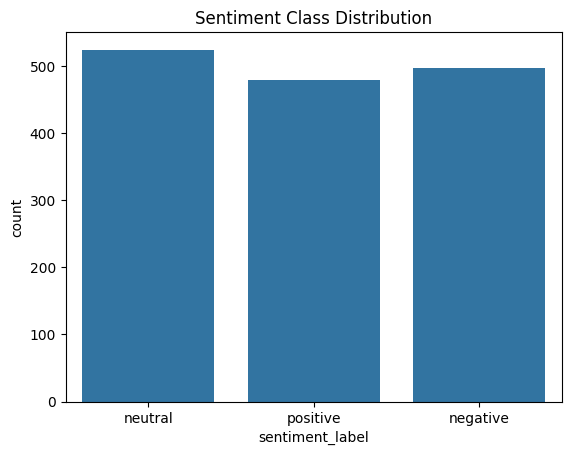

In [73]:
sns.countplot(x='sentiment_label',data=df)
plt.title('Sentiment Class Distribution')
plt.show()

NOTE:

The dataset contains customer support messages labeled with positive, neutral, or negative sentiment categories.

Dataset exploration helps understand class distribution and text characteristics before preprocessing and model training.

# Task 2: Text Preprocessing

In [74]:
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens
        if word not in stop_words]

    # Join tokens back into sentence
    cleaned_text = " ".join(tokens)
    return cleaned_text

In [75]:
# Applying preprocessing
nltk.download('punkt_tab')
df['cleaned_text'] = df['customer_message'].apply(preprocess_text)
df[['customer_message', 'cleaned_text']].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [76]:
# Tokenizer and sequences
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['cleaned_text'])
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

In [77]:
# Padding sequences
max_length = 50
X_padded = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post')
print("Padded sequence shape:", X_padded.shape)

Padded sequence shape: (1500, 50)


In [78]:
# Encoding target labels
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(df['sentiment_label'])
print("Classes:", encoder.classes_)

Classes: ['negative' 'neutral' 'positive']


NOTE:

The text data was preprocessed by converting text to lowercase, removing special characters, tokenizing words, and removing stopwords.

The cleaned text was then converted into numerical sequences and padded to a fixed length for sequence modeling.

# Task 3: Text Vectorization

In [79]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_text'])
print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (1500, 146)


NOTE:

Text data must be converted into numerical vectors because machine learning and deep learning models can only process numbers.

TF-IDF converts words into numerical representations based on their importance in the dataset.

Sequence tokenization converts text into ordered numerical sequences for sequence-based models like RNNs and LSTMs.

In [80]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42)

# Task 4: Baseline Model

In [81]:
# Logistic Regression model
baseline_model = LogisticRegression()
baseline_model.fit(X_train, y_train)

LogisticRegression()

In [82]:
# Predictions
y_pred = baseline_model.predict(X_test)

In [83]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



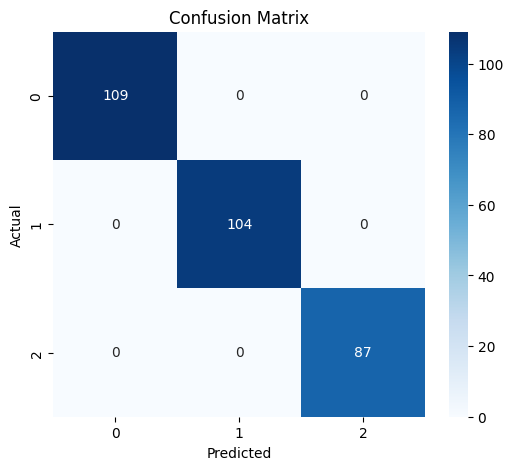

In [84]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [85]:
# Model accuracy
accuracy = baseline_model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [86]:
# Sample predictions
sample_texts = df['customer_message'].iloc[:5]
sample_vectors= tfidf.transform(sample_texts)
sample_predictions = baseline_model.predict(sample_vectors)
for i in range(5):
    print("Message:", sample_texts.iloc[i])
    print("Predicted Sentiment:",
          encoder.inverse_transform([sample_predictions[i]])[0])
    print("-" * 50)

Message: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Predicted Sentiment: neutral
--------------------------------------------------
Message: I need information about the payment process.
Predicted Sentiment: neutral
--------------------------------------------------
Message: The refund process was fast and convenient. I appreciate the quick response.
Predicted Sentiment: positive
--------------------------------------------------
Message: My refund is still pending and this experience is frustrating. My ticket number is 33927.
Predicted Sentiment: negative
--------------------------------------------------
Message: Please tell me how to update my account details.
Predicted Sentiment: neutral
--------------------------------------------------


NOTE:

The baseline Logistic Regression model with TF-IDF vectorization was able to classify customer support messages into sentiment categories.

TF-IDF helped represent text numerically based on word importance, allowing the classifier to learn sentiment-related patterns from the dataset.

# Task 5: Sequence Model /Conceptual Architecture

In [87]:
# Train-test split for sequence model
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_padded,
    y,
    test_size=0.2,
    random_state=42)

In [88]:
# LSTM model
lstm_model = Sequential()

# Embedding layer
lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length))

# LSTM layer
lstm_model.add(
    LSTM(64))

# Output layer
lstm_model.add(
    Dense(3, activation='softmax'))
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [89]:
# Training LSTM model
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.3531 - loss: 1.0999 - val_accuracy: 0.3292 - val_loss: 1.0999
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3552 - loss: 1.0990 - val_accuracy: 0.3292 - val_loss: 1.1000
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3354 - loss: 1.0994 - val_accuracy: 0.3292 - val_loss: 1.0998
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3552 - loss: 1.0993 - val_accuracy: 0.3292 - val_loss: 1.0999
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3708 - loss: 1.0961 - val_accuracy: 0.6667 - val_loss: 0.9801


In [90]:
# Evaluating LSTM model
loss, accuracy = lstm_model.evaluate(
    X_test_seq,
    y_test_seq)
print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6367 - loss: 0.9964
Test Accuracy: 0.6366666555404663


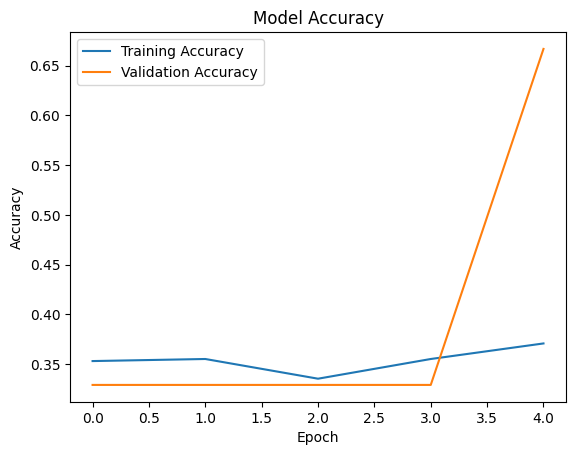

In [91]:
# Accuracy curves
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

NOTE:

The sequence model uses tokenized and padded input text sequences.

The embedding layer converts words into dense numerical vectors.

The LSTM layer processes the sequence while learning contextual relationships between words.

The output layer predicts the sentiment class using softmax activation.

- Loss Function:
Sparse Categorical Crossentropy

- Evaluation Metric:
Accuracy

# Task 6: Attention and Transformer Reflection

**Why do RNNs struggle with long-term dependencies?**

- RNNs process text sequentially and tend to forget information from earlier parts of long sequences.
- This makes it difficult for standard RNNs to capture long-term dependencies in text data.

**How do LSTMs help with memory?**

- LSTMs improve upon RNNs by using memory cells and gating mechanisms.
- These gates help the model decide what information to keep, update, or forget, allowing the network to retain important information over longer sequences.

**What does attention solve in sequence-to-sequence tasks?**

- Attention mechanisms allow the model to focus on the most relevant parts of the input sequence while generating outputs.
- This improves performance in tasks like translation and text summarization by avoiding the loss of important contextual information.

**Why are transformers important in modern NLP and Generative AI?**

- Transformers process entire sequences in parallel and use self-attention mechanisms to understand relationships between words efficiently.
- They are the foundation of modern NLP systems and Generative AI models such as ChatGPT because they achieve strong performance on large-scale language tasks.